### Noisy Data: Trial Run

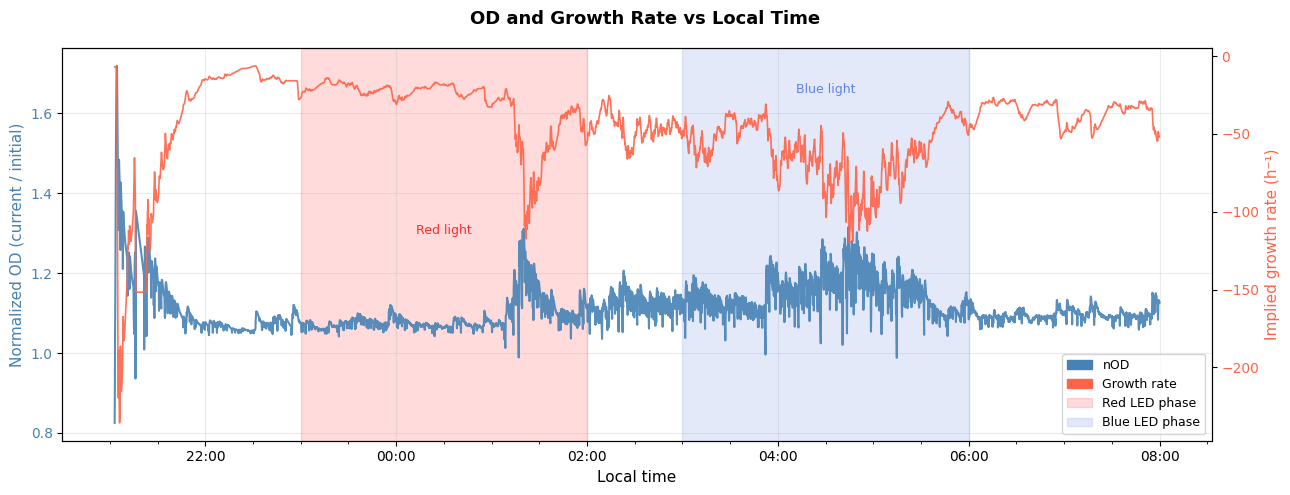

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

FILE_NOD = "./data/01st June (LED trial run)/od_readings_filtered-experiment_May-all_units-20260603000731.csv"
FILE_GR  = "./data/01st June (LED trial run)/growth_rates-experiment_May-all_units-20260603000731.csv"

nod = pd.read_csv(FILE_NOD)
gr = pd.read_csv(FILE_GR)

for df in [nod, gr]:
    df['timestamp_localtime'] = pd.to_datetime(df['timestamp_localtime'])

nod = nod.sort_values('timestamp_localtime')
gr = gr.sort_values('timestamp_localtime')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(nod['timestamp_localtime'],
               nod['normalized_od_reading'],
               color='steelblue', lw=1.5, alpha=0.9, label='nOD')
ax1.set_ylabel('Normalized OD (current / initial)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

l2, = ax2.plot(gr['timestamp_localtime'],
               gr['rate'],
               color='tomato', lw=1.2, alpha=0.9, label='Growth rate')
ax2.set_ylabel('Implied growth rate (h⁻¹)', fontsize=11, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_xlabel('Local time', fontsize=11)
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# ── LED phase shading ─────────────────────────────────────────────────────────
first_date = nod['timestamp_localtime'].dt.normalize().min()
red_start = first_date + pd.Timedelta(hours=23)
red_end = red_start + pd.Timedelta(hours=3)
blue_start = first_date + pd.Timedelta(days=1, hours=3)
blue_end = blue_start + pd.Timedelta(hours=3)

ax1.axvspan(red_start, red_end, color='red', alpha=0.14, label='Red LED phase')
ax1.axvspan(blue_start, blue_end, color='royalblue', alpha=0.14, label='Blue LED phase')
ax1.text(red_start + (red_end - red_start) / 2, ax1.get_ylim()[1] * 0.75,
         'Red light', color='red', fontsize=9, ha='center', va='top', alpha=0.8)
ax1.text(blue_start + (blue_end - blue_start) / 2, ax1.get_ylim()[1] * 0.95,
         'Blue light', color='royalblue', fontsize=9, ha='center', va='top', alpha=0.8)

ax1.grid(True, alpha=0.25, zorder=0)
legend_handles = [Patch(color='steelblue', label='nOD'), Patch(color='tomato', label='Growth rate'),
                  Patch(color='red', alpha=0.14, label='Red LED phase'),
                  Patch(color='royalblue', alpha=0.14, label='Blue LED phase')]
ax1.legend(handles=legend_handles, loc='lower right', fontsize=9)

fig.suptitle('OD and Growth Rate vs Local Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Experiment: Trial run - Flashing blue LED light for 3 hours

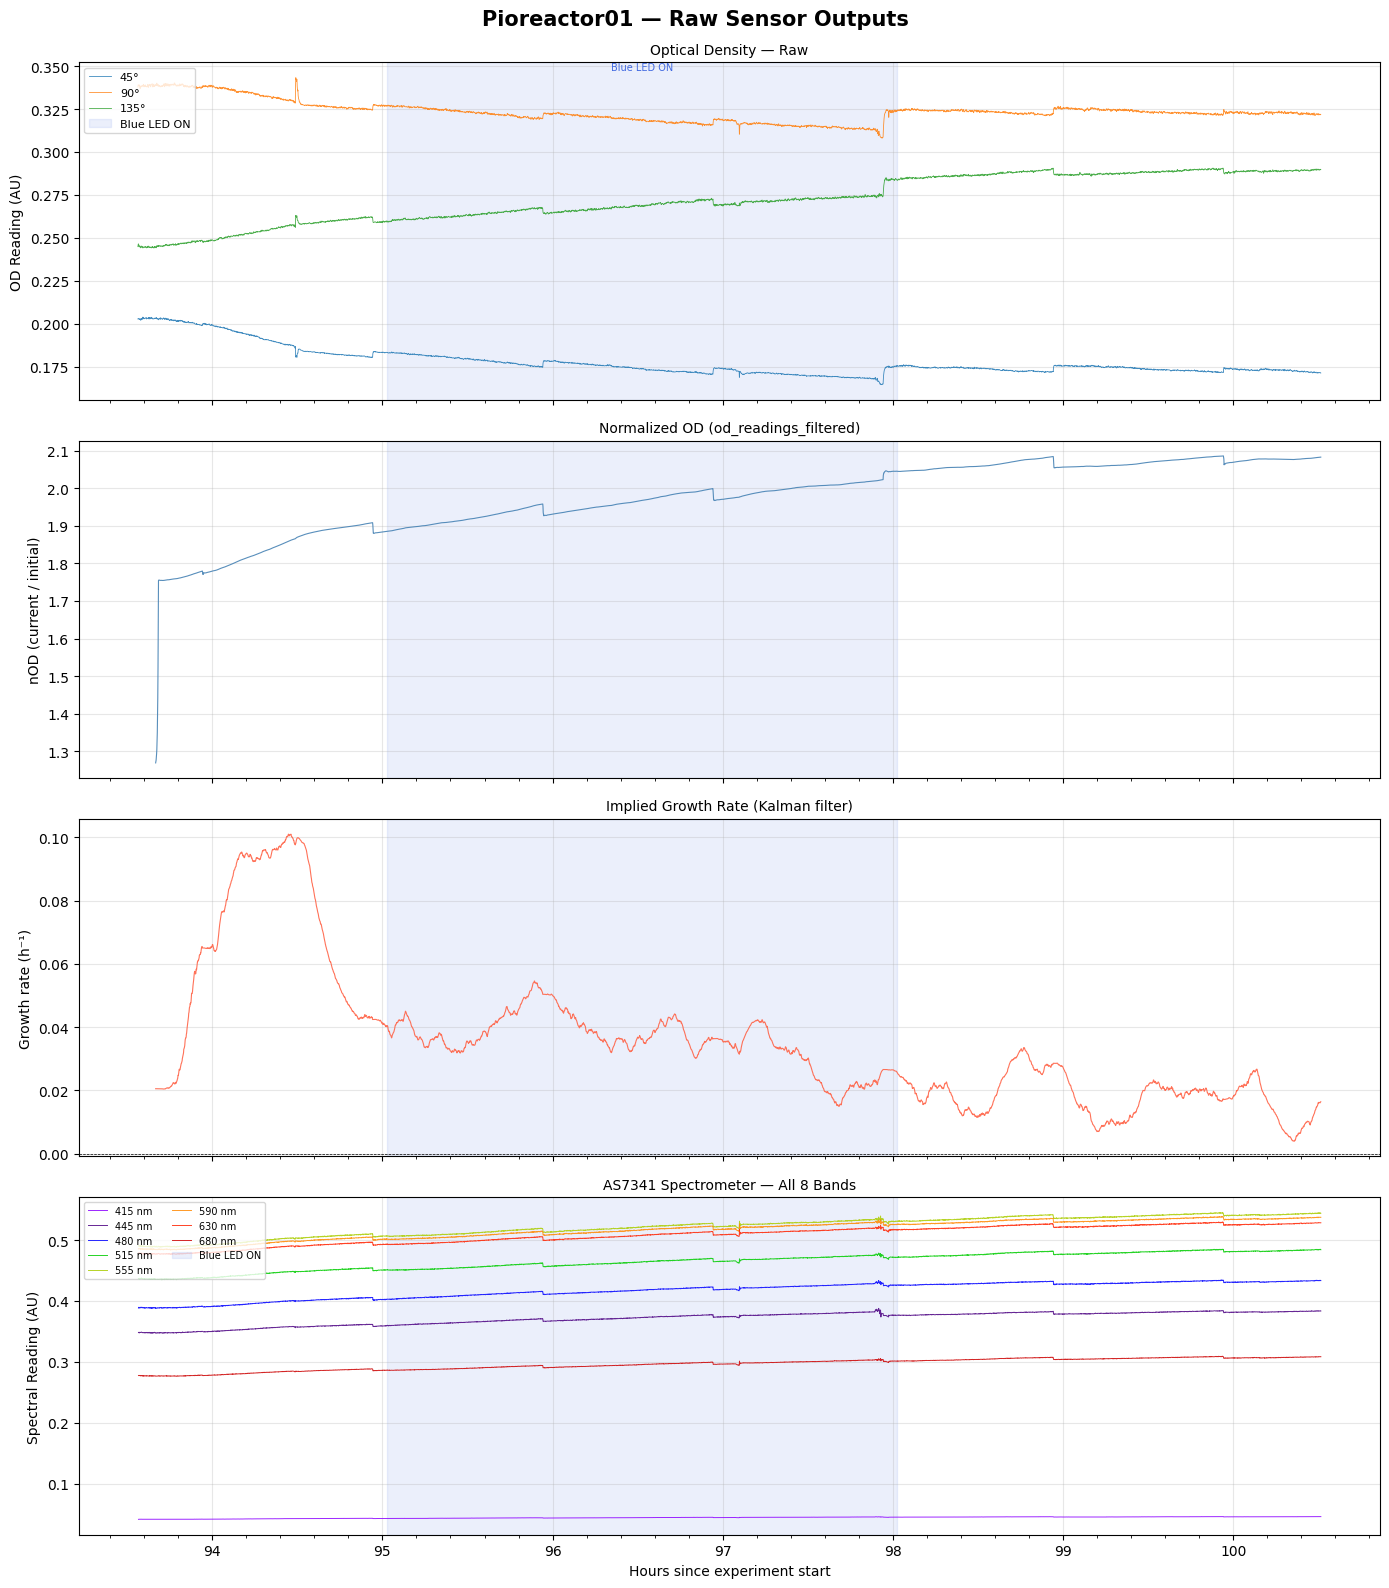

In [ ]:
# Plot: all raw sensor outputs in 4 subplots:
#   1. OD readings (all angles)
#   2. Normalized OD (od_readings_filtered)
#   3. Implied growth rate
#   4. AS7341 spectrometer (all 8 bands)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD         = "./data/02nd June (effect of blue LED)/od_readings-experiment_May-pioreactor01-20260602224829.csv"
FILE_NOD        = "./data/02nd June (effect of blue LED)/od_readings_filtered-experiment_May-pioreactor01-20260602224829.csv"
FILE_GR         = "./data/02nd June (effect of blue LED)/growth_rates-experiment_May-pioreactor01-20260602224829.csv"
FILE_SPEC       = "./data/02nd June (effect of blue LED)/as7341_spectrum_readings-experiment_May-pioreactor01-20260602224829.csv"
FILE_LED        = "./data/02nd June (effect of blue LED)/led_change_events-experiment_May-pioreactor01-20260602224829.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
od   = pd.read_csv(FILE_OD)
nod  = pd.read_csv(FILE_NOD)
gr   = pd.read_csv(FILE_GR)
spec = pd.read_csv(FILE_SPEC)
led  = pd.read_csv(FILE_LED)

# ── LED phase boundaries (channel C = blue LED) ───────────────────────────────
# Find ON and OFF events for channel C
led_C = led[led['channel'] == 'C'].sort_values('hours_since_experiment_created')
blue_on  = led_C[led_C['intensity'] > 0]['hours_since_experiment_created'].values
blue_off = led_C[led_C['intensity'] == 0]['hours_since_experiment_created'].values

def shade_blue_phases(ax):
    """Shade blue LED ON windows on a given axis."""
    for on, off in zip(blue_on, blue_off):
        ax.axvspan(on, off, color='royalblue', alpha=0.10, label='Blue LED ON')

# ── Spectrometer: pivot so each band is a column ──────────────────────────────
spec_pivot = spec.pivot_table(
    index='hours_since_experiment_created',
    columns='band',
    values='reading',
    aggfunc='mean'
).reset_index()

BAND_COLORS = {
    415: '#8B00FF',  # violet
    445: '#4B0082',  # indigo
    480: '#0000FF',  # blue
    515: '#00CC00',  # green
    555: '#AACC00',  # yellow-green
    590: '#FF8800',  # orange
    630: '#FF2200',  # red-orange
    680: '#CC0000',  # deep red
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.suptitle('Pioreactor01 — Raw Sensor Outputs', fontsize=15, fontweight='bold', y=0.99)

# ── Subplot 1: OD readings (all angles) ───────────────────────────────────────
ax1 = axes[0]
angle_styles = {45: ('tab:blue', '-'), 90: ('tab:orange', '-'), 135: ('tab:green', '-')}
for angle, (color, ls) in angle_styles.items():
    sub = od[od['angle'] == angle].sort_values('hours_since_experiment_created')
    ax1.plot(sub['hours_since_experiment_created'], sub['od_reading'],
             color=color, lw=0.6, linestyle=ls, label=f'{angle}°', alpha=0.85)
shade_blue_phases(ax1)
ax1.set_ylabel('OD Reading (AU)', fontsize=10)
ax1.set_title('Optical Density — Raw', fontsize=10)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('hours_since_experiment_created')
ax2.plot(nod_s['hours_since_experiment_created'], nod_s['normalized_od_reading'],
         color='steelblue', lw=0.8, alpha=0.9)
shade_blue_phases(ax2)
ax2.set_ylabel('nOD (current / initial)', fontsize=10)
ax2.set_title('Normalized OD (od_readings_filtered)', fontsize=10)
ax2.grid(True, alpha=0.3)

# ── Subplot 3: Implied growth rate ────────────────────────────────────────────
ax3 = axes[2]
gr_s = gr.sort_values('hours_since_experiment_created')
ax3.plot(gr_s['hours_since_experiment_created'], gr_s['rate'],
         color='tomato', lw=0.8, alpha=0.9)
shade_blue_phases(ax3)
ax3.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax3.set_title('Implied Growth Rate (Kalman filter)', fontsize=10)
ax3.axhline(0, color='black', lw=0.5, linestyle='--')
ax3.grid(True, alpha=0.3)

# ── Subplot 4: AS7341 spectrometer ────────────────────────────────────────────
ax4 = axes[3]
for band in sorted(spec_pivot.columns[1:]):
    ax4.plot(spec_pivot['hours_since_experiment_created'], spec_pivot[band],
             color=BAND_COLORS.get(band, 'grey'), lw=0.7,
             label=f'{band} nm', alpha=0.85)
shade_blue_phases(ax4)
ax4.set_ylabel('Spectral Reading (AU)', fontsize=10)
ax4.set_title('AS7341 Spectrometer — All 8 Bands', fontsize=10)
ax4.set_xlabel('Hours since experiment start', fontsize=10)
ax4.legend(loc='upper left', fontsize=7, ncol=2)
ax4.grid(True, alpha=0.3)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# Add blue LED annotation on top subplot
for on, off in zip(blue_on, blue_off):
    axes[0].annotate('Blue LED ON',
                     xy=((on + off) / 2, axes[0].get_ylim()[1]),
                     fontsize=7, color='royalblue', ha='center', va='top')

plt.tight_layout()
plt.show()


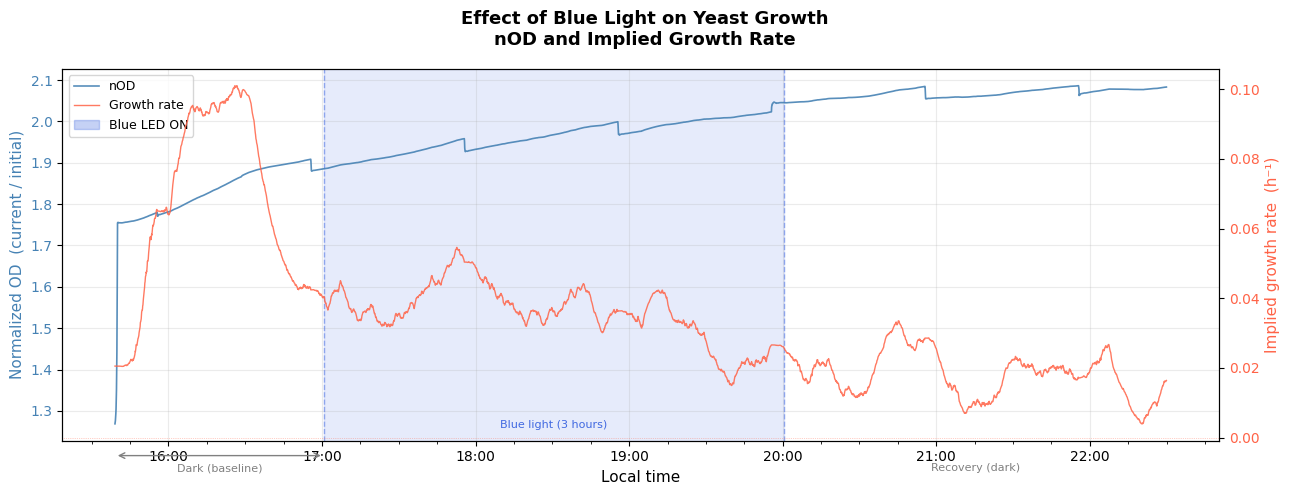

In [ ]:
# Plot: implied growth rate and normalized OD with the blue LED phase shaded in blue.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# ── File paths ────────────────────────────────────────────────────────────────
FILE_NOD = "./data/02nd June (effect of blue LED)/od_readings_filtered-experiment_May-pioreactor01-20260602224829.csv"
FILE_GR = "./data/02nd June (effect of blue LED)/growth_rates-experiment_May-pioreactor01-20260602224829.csv"
FILE_LED  = "./data/02nd June (effect of blue LED)/led_change_events-experiment_May-pioreactor01-20260602224829.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
nod = pd.read_csv(FILE_NOD)
gr  = pd.read_csv(FILE_GR)
led = pd.read_csv(FILE_LED)

for df in [nod, gr, led]:
    df['timestamp_localtime'] = pd.to_datetime(df['timestamp_localtime'])

nod = nod.sort_values('timestamp_localtime')
gr = gr.sort_values('timestamp_localtime')
led = led.sort_values('timestamp_localtime')

# ── LED phase boundaries ──────────────────────────────────────────────────────
led_C    = led[led['channel'] == 'C'].sort_values('timestamp_localtime')
blue_on  = led_C[led_C['intensity'] > 0]['timestamp_localtime'].values
blue_off = led_C[led_C['intensity'] == 0]['timestamp_localtime'].values

# ── Figure: two y-axes sharing one x-axis ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# ── Blue LED shading ──────────────────────────────────────────────────────────
for i, (on, off) in enumerate(zip(blue_on, blue_off)):
    label = 'Blue LED ON' if i == 0 else '_nolegend_'
    ax1.axvspan(on, off,
                color='royalblue', alpha=0.13, zorder=0, label=label)
    # Bracket lines at phase boundaries
    for t in [on, off]:
        ax1.axvline(t, color='royalblue', lw=1.0, linestyle='--', alpha=0.5)
    # Phase label at top
    mid = on + (off - on) / 2

# ── nOD (left axis) ───────────────────────────────────────────────────────────
l1, = ax1.plot(nod['timestamp_localtime'],
               nod['normalized_od_reading'],
               color='steelblue', lw=1.2, alpha=0.9, label='nOD', zorder=2)
ax1.set_ylabel('Normalized OD  (current / initial)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Local time', fontsize=11)

# ── Growth rate (right axis) ──────────────────────────────────────────────────
l2, = ax2.plot(gr['timestamp_localtime'],
               gr['rate'],
               color='tomato', lw=1.0, alpha=0.85, label='Growth rate', zorder=2)
ax2.set_ylabel('Implied growth rate  (h⁻¹)', fontsize=11, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.axhline(0, color='tomato', lw=0.5, linestyle=':', alpha=0.6)

# ── Phase annotations on x-axis ───────────────────────────────────────────────
x_min = pd.to_datetime(min(nod['timestamp_localtime'].min(),
                           gr['timestamp_localtime'].min()))
x_max = pd.to_datetime(max(nod['timestamp_localtime'].max(),
                           gr['timestamp_localtime'].max()))

if len(blue_on) > 0:
    # Dark before
    ax1.annotate('', xy=(blue_on[0], -0.04), xytext=(x_min, -0.04),
                 xycoords=('data', 'axes fraction'),
                 textcoords=('data', 'axes fraction'),
                 arrowprops=dict(arrowstyle='<->', color='grey', lw=1))
    dark_mid = x_min + (blue_on[0] - x_min) / 2
    ax1.text(dark_mid, -0.06, 'Dark (baseline)',
             ha='center', va='top', fontsize=8, color='grey',
             transform=ax1.get_xaxis_transform())
    # Blue phase
    blue_mid = blue_on[0] + (blue_off[0] - blue_on[0]) / 2
    ax1.text(blue_mid, 0.03, 'Blue light (3 hours)',
             ha='center', va='bottom', fontsize=8, color='royalblue',
             transform=ax1.get_xaxis_transform())
    # Recovery
    recovery_mid = blue_off[0] + (x_max - blue_off[0]) / 2
    ax1.text(recovery_mid, -0.06, 'Recovery (dark)',
             ha='center', va='top', fontsize=8, color='grey',
             transform=ax1.get_xaxis_transform())

# ── Legend, grid, title ───────────────────────────────────────────────────────
lines = [l1, l2]
labels = [l.get_label() for l in lines]
# Add blue LED patch to legend
from matplotlib.patches import Patch
blue_patch = Patch(color='royalblue', alpha=0.3, label='Blue LED ON')
ax1.legend(handles=[l1, l2, blue_patch], loc='upper left', fontsize=9)

ax1.grid(True, alpha=0.25, zorder=0)
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

fig.suptitle('Effect of Blue Light on Yeast Growth\n'
             'nOD and Implied Growth Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### Experiment: Red & Blue light phases run

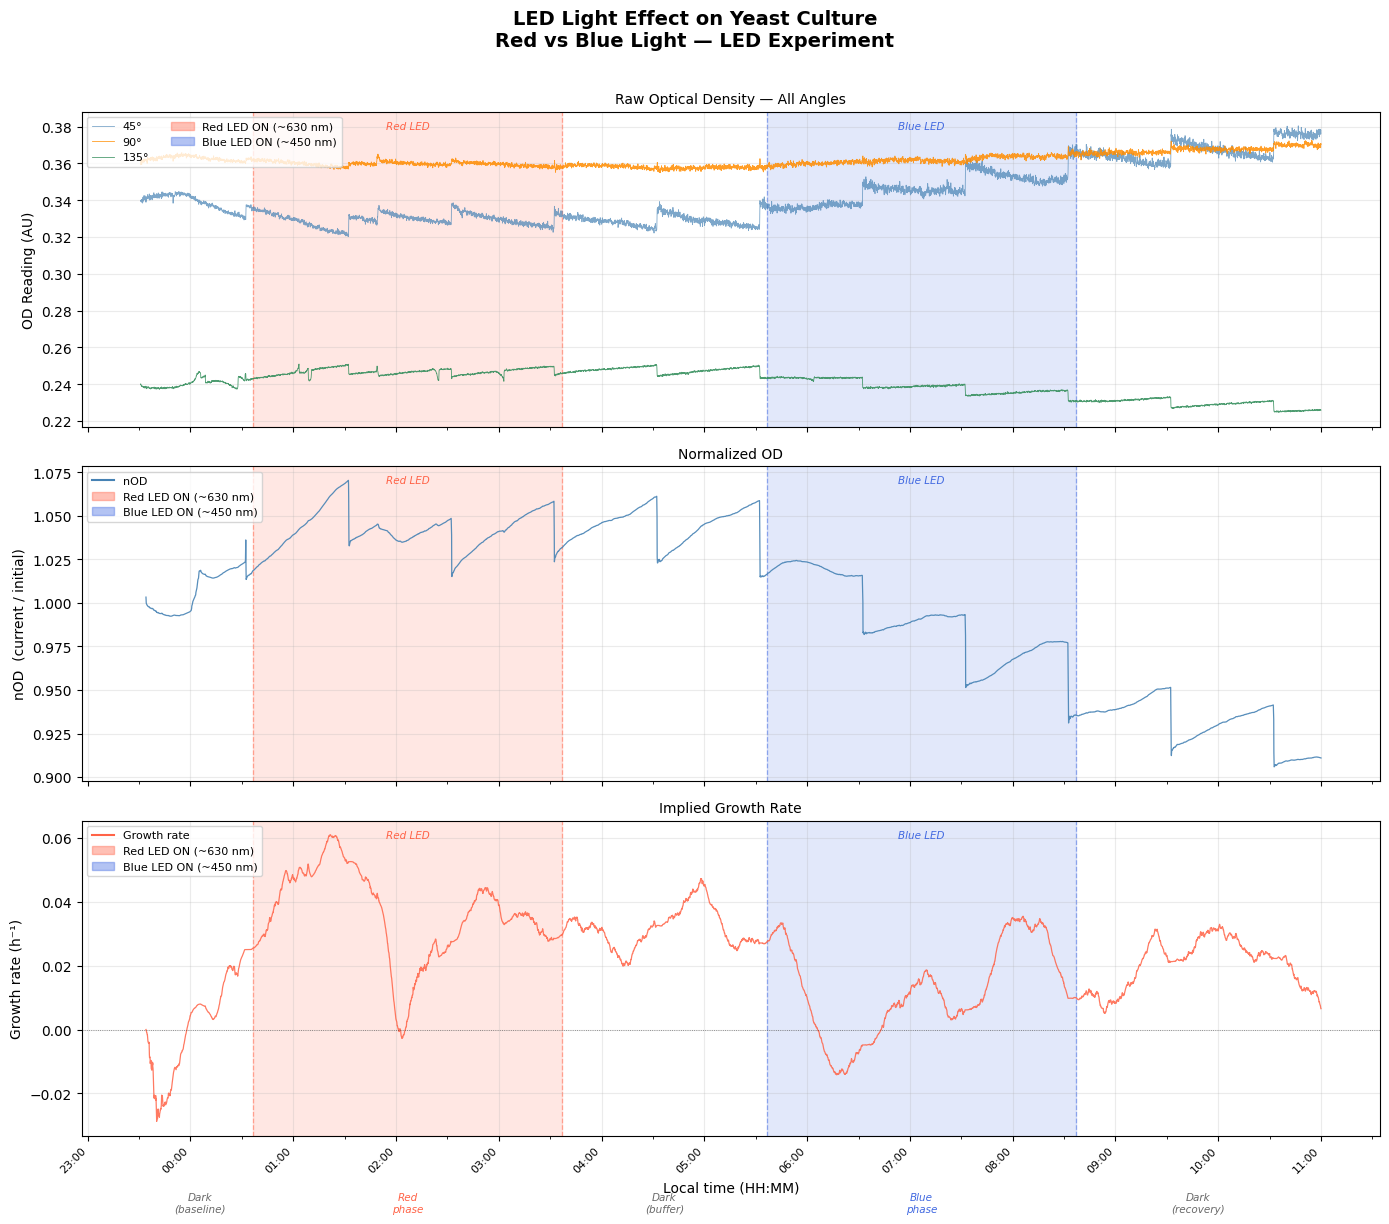

Saved: led_experiment_phases.png


In [ ]:
# 3 subplots: Raw OD | Normalized OD | Growth Rate
# Red phase (Channel C) and Blue phase (Channel D) shaded in their colours.
# X-axis: local time (HH:MM)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD   = "./data/03rd June (LED automation)/od_readings-LED_experiment-all_units-20260603115056.csv"
FILE_NOD  = "./data/03rd June (LED automation)/od_readings_filtered-LED_experiment-all_units-20260603115056.csv"
FILE_GR   = "./data/03rd June (LED automation)/growth_rates-LED_experiment-all_units-20260603115056.csv"
FILE_LED  = "./data/03rd June (LED automation)/led_change_events-LED_experiment-all_units-20260603115056.csv"

# ── Load & parse timestamps ───────────────────────────────────────────────────
od  = pd.read_csv(FILE_OD)
nod = pd.read_csv(FILE_NOD)
gr  = pd.read_csv(FILE_GR)
led = pd.read_csv(FILE_LED)

for df in [od, nod, gr, led]:
    df['t'] = pd.to_datetime(df['timestamp_localtime'])

led = led.sort_values('t')

# ── Resolve phase windows from LED events ─────────────────────────────────────
# Channel C = Red LED (~630 nm)
# Channel D = Blue LED (~450 nm)
def get_phases(led_df, channel):
    """Return list of (on_time, off_time) datetime tuples for a given channel."""
    events = led_df[led_df['channel'] == channel].sort_values('t')
    phases, on_time = [], None
    for _, row in events.iterrows():
        if row['intensity'] > 0 and on_time is None:
            on_time = row['t']
        elif row['intensity'] == 0 and on_time is not None:
            phases.append((on_time, row['t']))
            on_time = None
    return phases

red_phases  = get_phases(led, 'C')   # Channel C = Red
blue_phases = get_phases(led, 'D')   # Channel D = Blue

# ── Shading helper ────────────────────────────────────────────────────────────
def shade_phases(ax):
    for on, off in red_phases:
        ax.axvspan(on, off, color='tomato', alpha=0.15, zorder=0)
        ax.axvline(on,  color='tomato', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.axvline(off, color='tomato', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.text(on + (off - on) / 2, 0.97, 'Red LED',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=7.5, color='tomato', style='italic')
    for on, off in blue_phases:
        ax.axvspan(on, off, color='royalblue', alpha=0.15, zorder=0)
        ax.axvline(on,  color='royalblue', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.axvline(off, color='royalblue', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.text(on + (off - on) / 2, 0.97, 'Blue LED',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=7.5, color='royalblue', style='italic')

# ── X-axis formatter (applied to bottom subplot only; sharex propagates) ──────
def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# ── Legend patches ────────────────────────────────────────────────────────────
legend_patches = [
    Patch(color='tomato',    alpha=0.4, label='Red LED ON (~630 nm)'),
    Patch(color='royalblue', alpha=0.4, label='Blue LED ON (~450 nm)'),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('LED Light Effect on Yeast Culture\nRed vs Blue Light — LED Experiment',
             fontsize=14, fontweight='bold', y=1.01)

# ── Subplot 1: Raw OD (all angles) ────────────────────────────────────────────
ax1 = axes[0]
angle_cfg = {45: ('steelblue', 0.7), 90: ('darkorange', 0.85), 135: ('seagreen', 0.85)}
for angle, (color, alpha) in angle_cfg.items():
    sub = od[od['angle'] == angle].sort_values('t')
    ax1.plot(sub['t'], sub['od_reading'],
             color=color, lw=0.6, alpha=alpha, label=f'{angle}°')
shade_phases(ax1)
ax1.set_ylabel('OD Reading (AU)', fontsize=10)
ax1.set_title('Raw Optical Density — All Angles', fontsize=10)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + legend_patches,
           labels=labels + [p.get_label() for p in legend_patches],
           loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.25)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('t')
ax2.plot(nod_s['t'], nod_s['normalized_od_reading'],
         color='steelblue', lw=0.9, alpha=0.9)
shade_phases(ax2)
ax2.set_ylabel('nOD  (current / initial)', fontsize=10)
ax2.set_title('Normalized OD', fontsize=10)
ax2.legend(handles=[plt.Line2D([0],[0], color='steelblue', lw=1.5, label='nOD')] + legend_patches,
           loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.25)

# ── Subplot 3: Implied growth rate ────────────────────────────────────────────
ax3 = axes[2]
gr_s = gr.sort_values('t')
ax3.plot(gr_s['t'], gr_s['rate'],
         color='tomato', lw=0.9, alpha=0.85)
ax3.axhline(0, color='black', lw=0.6, ls=':', alpha=0.5)
shade_phases(ax3)
ax3.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax3.set_title('Implied Growth Rate', fontsize=10)
ax3.set_xlabel('Local time (HH:MM)', fontsize=10)
ax3.legend(handles=[plt.Line2D([0],[0], color='tomato', lw=1.5, label='Growth rate')] + legend_patches,
           loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.25)

# ── Phase labels below x-axis ─────────────────────────────────────────────────
t_min = gr_s['t'].min()
t_max = gr_s['t'].max()
phase_labels = [
    (t_min,             red_phases[0][0],  'Dark\n(baseline)', 'dimgrey'),
    (red_phases[0][0],  red_phases[0][1],  'Red\nphase',       'tomato'),
    (red_phases[0][1],  blue_phases[0][0], 'Dark\n(buffer)',   'dimgrey'),
    (blue_phases[0][0], blue_phases[0][1], 'Blue\nphase',      'royalblue'),
    (blue_phases[0][1], t_max,             'Dark\n(recovery)', 'dimgrey'),
]
for x0, x1, label, color in phase_labels:
    mid = x0 + (x1 - x0) / 2
    ax3.text(mid, -0.18, label,
             transform=ax3.get_xaxis_transform(),
             ha='center', va='top', fontsize=7.5, color=color, style='italic')

# ── Format x-axis (bottom subplot only; sharex propagates ticks up) ───────────
fmt_xaxis(ax3)

plt.tight_layout()
plt.show()


### LED Experiment 01

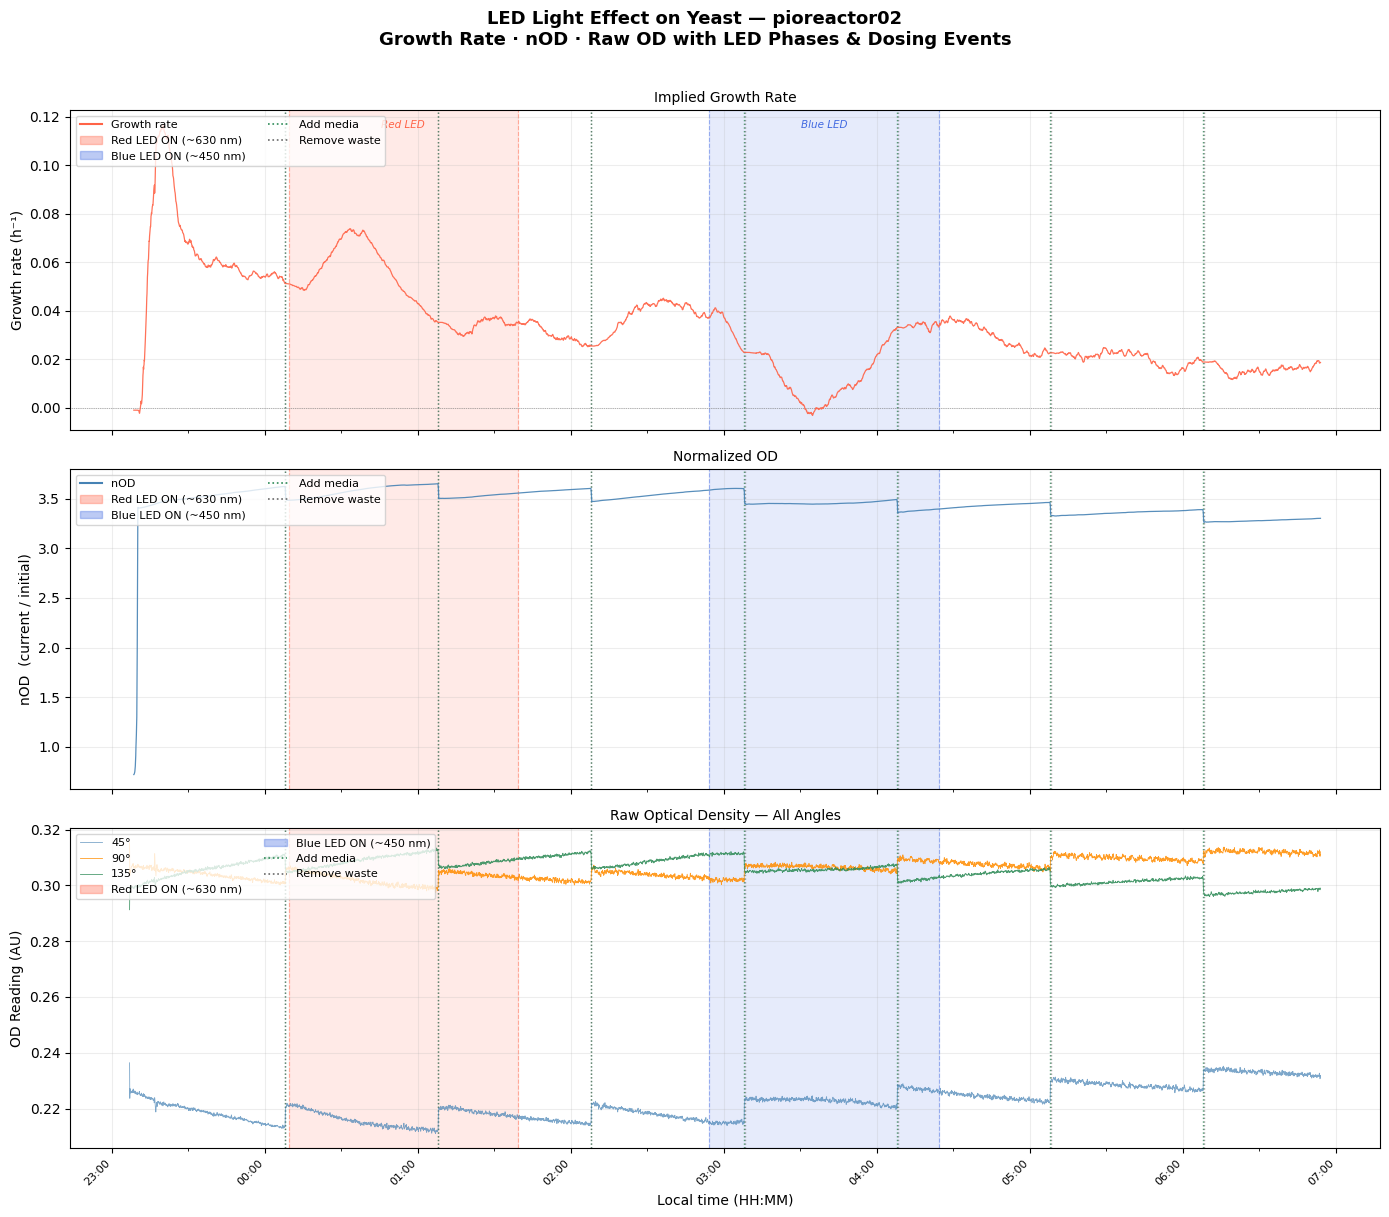

In [2]:
# 3 subplots: Growth Rate | nOD | Raw OD
# Each subplot has:
#   - Red/Blue LED phases shaded
#   - Dosing events marked as vertical lines (add_media=green, remove_waste=grey)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD     = "./data/LED run 01/od_readings-LED_experiment-pioreactor02-20260606143542.csv"
FILE_NOD    = "./data/LED run 01/od_readings_filtered-LED_experiment-pioreactor02-20260606143542.csv"
FILE_GR     = "./data/LED run 01/growth_rates-LED_experiment-pioreactor02-20260606143542.csv"
FILE_LED    = "./data/LED run 01/led_change_events-LED_experiment-pioreactor02-20260606143542.csv"
FILE_DOSING = "./data/LED run 01/dosing_events-LED_experiment-pioreactor02-20260606143542.csv"

# ── Load & parse timestamps ───────────────────────────────────────────────────
od     = pd.read_csv(FILE_OD)
nod    = pd.read_csv(FILE_NOD)
gr     = pd.read_csv(FILE_GR)
led    = pd.read_csv(FILE_LED)
dosing = pd.read_csv(FILE_DOSING)

for df in [od, nod, gr, led, dosing]:
    df['t'] = pd.to_datetime(df['timestamp_localtime'])

# ── LED phases ────────────────────────────────────────────────────────────────
def get_phases(led_df, channel):
    events = led_df[led_df['channel'] == channel].sort_values('t')
    phases, on_time = [], None
    for _, row in events.iterrows():
        if row['intensity'] > 0 and on_time is None:
            on_time = row['t']
        elif row['intensity'] == 0 and on_time is not None:
            phases.append((on_time, row['t']))
            on_time = None
    return phases

red_phases  = get_phases(led, 'C')
blue_phases = get_phases(led, 'D')

# ── Dosing bursts (gap > 5 s = new burst) ────────────────────────────────────
dosing = dosing.sort_values('t')
dosing['gap'] = dosing['t'].diff().dt.total_seconds().fillna(999)
burst_starts = dosing[dosing['gap'] > 5].copy()
add_media_t    = burst_starts[burst_starts['event'] == 'add_media']['t']
remove_waste_t = burst_starts[burst_starts['event'] == 'remove_waste']['t']

# ── Shared shade + dosing helper ──────────────────────────────────────────────
def annotate_ax(ax, show_labels=False):
    # LED phase shading
    for on, off in red_phases:
        ax.axvspan(on, off, color='tomato', alpha=0.13, zorder=0)
        ax.axvline(on,  color='tomato', lw=0.8, ls='--', alpha=0.45, zorder=1)
        ax.axvline(off, color='tomato', lw=0.8, ls='--', alpha=0.45, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'Red LED',
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7.5,
                    color='tomato', style='italic')
    for on, off in blue_phases:
        ax.axvspan(on, off, color='royalblue', alpha=0.13, zorder=0)
        ax.axvline(on,  color='royalblue', lw=0.8, ls='--', alpha=0.45, zorder=1)
        ax.axvline(off, color='royalblue', lw=0.8, ls='--', alpha=0.45, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'Blue LED',
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7.5,
                    color='royalblue', style='italic')
    # Dosing events
    for t in add_media_t:
        ax.axvline(t, color='seagreen', lw=1.0, ls=':', alpha=0.8, zorder=2)
    for t in remove_waste_t:
        ax.axvline(t, color='dimgrey', lw=1.0, ls=':', alpha=0.6, zorder=2)

# ── Legend handles ────────────────────────────────────────────────────────────
legend_elements = [
    Patch(color='tomato',    alpha=0.35, label='Red LED ON (~630 nm)'),
    Patch(color='royalblue', alpha=0.35, label='Blue LED ON (~450 nm)'),
    Line2D([0],[0], color='seagreen', lw=1.2, ls=':', label='Add media'),
    Line2D([0],[0], color='dimgrey',  lw=1.2, ls=':', label='Remove waste'),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('LED Light Effect on Yeast — pioreactor02\nGrowth Rate · nOD · Raw OD with LED Phases & Dosing Events',
             fontsize=13, fontweight='bold', y=1.01)

# ── Subplot 1: Growth rate ────────────────────────────────────────────────────
ax1 = axes[0]
gr_s = gr.sort_values('t')
ax1.plot(gr_s['t'], gr_s['rate'], color='tomato', lw=0.9, alpha=0.9, zorder=3)
ax1.axhline(0, color='black', lw=0.5, ls=':', alpha=0.5)
annotate_ax(ax1, show_labels=True)
ax1.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax1.set_title('Implied Growth Rate', fontsize=10)
ax1.legend(handles=[Line2D([0],[0], color='tomato', lw=1.5, label='Growth rate')] + legend_elements,
           loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.22)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('t')
ax2.plot(nod_s['t'], nod_s['normalized_od_reading'], color='steelblue', lw=0.9, alpha=0.9, zorder=3)
annotate_ax(ax2)
ax2.set_ylabel('nOD  (current / initial)', fontsize=10)
ax2.set_title('Normalized OD', fontsize=10)
ax2.legend(handles=[Line2D([0],[0], color='steelblue', lw=1.5, label='nOD')] + legend_elements,
           loc='upper left', fontsize=8, ncol=2)
ax2.grid(True, alpha=0.22)

# ── Subplot 3: Raw OD (all angles) ────────────────────────────────────────────
ax3 = axes[2]
angle_cfg = {45: ('steelblue', 0.70), 90: ('darkorange', 0.85), 135: ('seagreen', 0.85)}
for angle, (color, alpha) in angle_cfg.items():
    sub = od[od['angle'] == angle].sort_values('t')
    ax3.plot(sub['t'], sub['od_reading'], color=color, lw=0.6, alpha=alpha,
             label=f'{angle}°', zorder=3)
annotate_ax(ax3)
ax3.set_ylabel('OD Reading (AU)', fontsize=10)
ax3.set_title('Raw Optical Density — All Angles', fontsize=10)
ax3.set_xlabel('Local time (HH:MM)', fontsize=10)
od_handles, od_labels = ax3.get_legend_handles_labels()
ax3.legend(handles=od_handles + legend_elements,
           labels=od_labels + [e.get_label() for e in legend_elements],
           loc='upper left', fontsize=8, ncol=2)
ax3.grid(True, alpha=0.22)

# ── X-axis formatting (bottom only; sharex propagates) ───────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax3.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()
